In [7]:
import numpy as np
import matplotlib.pyplot as plt
import skyproj, healpy as hp, h5py, fitsio
from scipy import stats
import pandas as pd
import skyproj

import os
if os.environ['USER'] == 'dhayaa':
    os.environ['PATH'] = f"{os.environ['PATH']}:/software/texlive-2023/bin/x86_64-linux"

plt.rcParams["axes.linewidth"]  = 1.0
plt.rcParams["xtick.major.size"]  = 10
plt.rcParams["xtick.minor.size"]  = 5
plt.rcParams["ytick.major.size"]  = 10
plt.rcParams["ytick.minor.size"]  = 5
plt.rcParams["xtick.direction"]  = "in"
plt.rcParams["ytick.direction"]  = "in"
plt.rcParams["legend.frameon"] = 'False'
plt.rcParams['figure.figsize'] = [10, 10]
plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=24)

if os.environ['USER'] == 'dhayaa':
    os.environ['PATH'] = f"{os.environ['PATH']}:/software/texlive-2022-el8-x86_64/bin/x86_64-linux/"


COLORS = ["f07167","219ebc","ffba0a","c767ac","59a270"]
COLORS = ['#' + c if c[0] != '#' else c for c in COLORS ]

# Update the default prop_cycle
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=COLORS)


from matplotlib.colors import LinearSegmentedColormap, ListedColormap
custom_cmap = LinearSegmentedColormap.from_list(None, [COLORS[1], 'white', COLORS[3]])
# custom_cmap.set_bad(color = 'k', alpha = 0.02)
def discretize_cmap(cmap, num_colors): return ListedColormap([cmap(i / (num_colors - 1)) for i in range(num_colors)])

In [2]:
All_specz = pd.read_csv('/project/kadrlica/dhayaa/Redmapper/Specz_Catalog.csv', low_memory = False)
DES_specs = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DESEli_20260314/Files/Eli.train_specz.fits')
DEC_specs = fitsio.read('/project/kadrlica/dhayaa/Redmapper/DECADEEli_20260314/Files/Eli.train_specz.fits')

In [3]:
from numpy.lib import recfunctions as rfn

def add_source(spec):
    key = pd.DataFrame({'RA':spec['ra'].astype(float).round(6), 'DEC':spec['dec'].astype(float).round(6), 'Z':spec['z'].astype(float).round(6)})
    ref = All_specz[['RA','DEC','Z','SOURCE']].copy()
    ref[['RA','DEC','Z']] = ref[['RA','DEC','Z']].round(6)
    src = key.merge(ref.drop_duplicates(['RA','DEC','Z']), on=['RA','DEC','Z'], how='left', sort=False)['SOURCE'].fillna('NONE').astype(str).to_numpy()
    return rfn.append_fields(spec, 'source', src.astype(f'U{max(map(len, src))}'), usemask=False)

DES_specs, DEC_specs = add_source(DES_specs), add_source(DEC_specs)

In [4]:
LABELS = {
    'DESI_BGS_ANY' : 'DESI BGS',
    'DESI_LRG' : 'DESI LRGs',
    'DESI_ELG_LOPnotqso' : 'DESI ELGs',
    'SDSS_DR16' : 'SDSS DR16',
    'VIPERS' : 'VIPERS',
    'GAMA' : 'GAMA',
    '2dFLenS' : '2dFLenS',
    '2DF' : '2DF',
    '6DF' : '6DF',
}

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


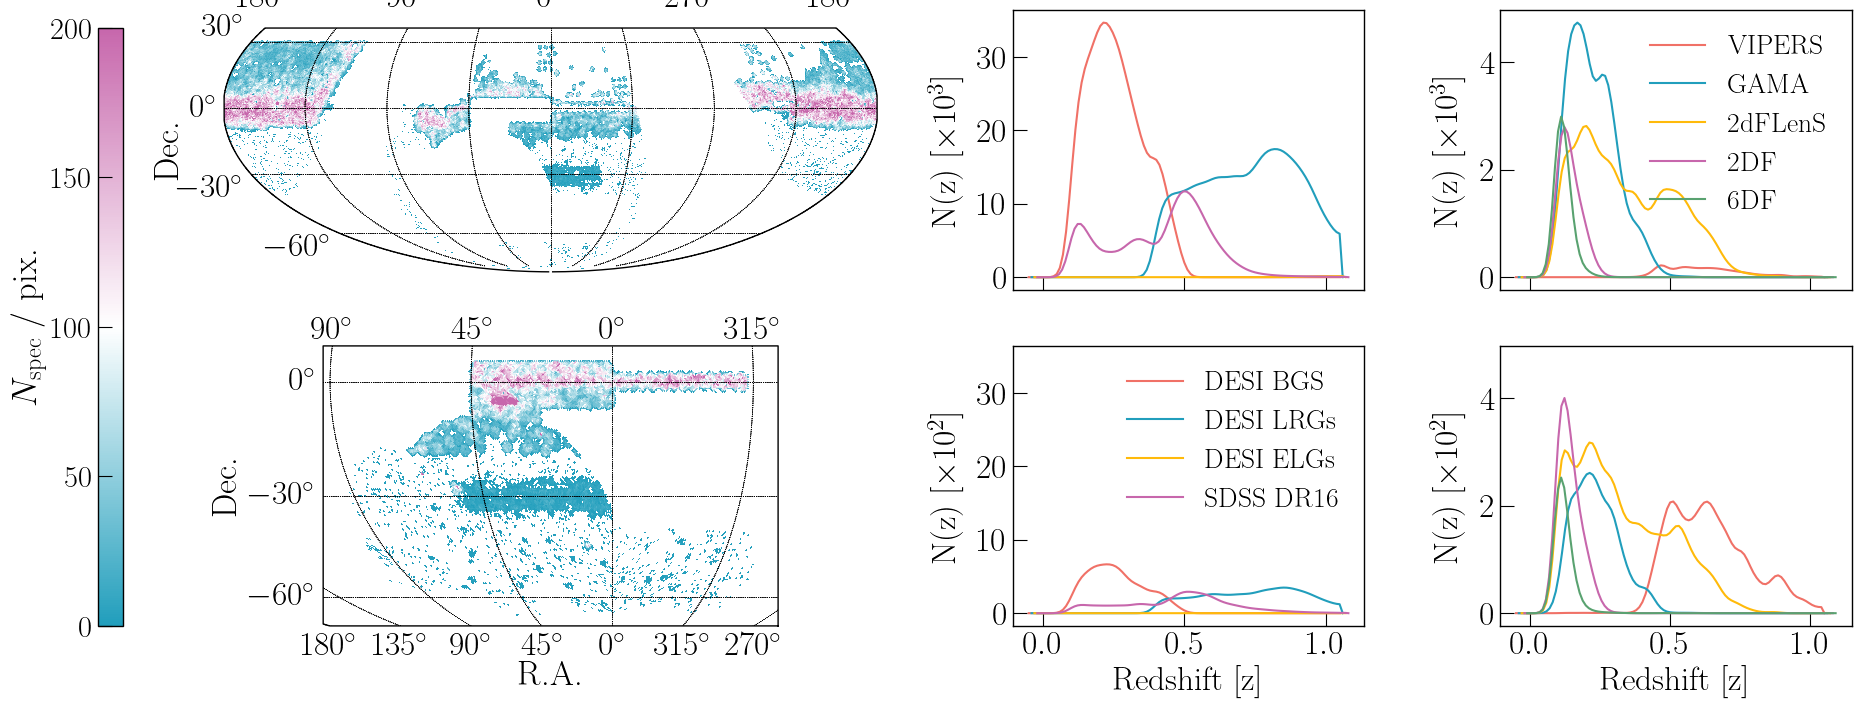

In [15]:
%matplotlib inline

from scipy.ndimage import gaussian_filter1d

fig, ax = plt.subplots(2, 3, figsize=(21, 8), sharey = 'col', sharex = 'col', gridspec_kw = {'width_ratios' : [1.3, 0.7, 0.7]})
plt.subplots_adjust(wspace = 0.3)

map_axes = []
for a, D, title in zip(ax[:, 0], [DEC_specs, DES_specs], ['DEC', 'DES']):
    hmap = np.bincount(hp.ang2pix(128, D['ra'], D['dec'], lonlat=True), minlength=hp.nside2npix(128))
    hmap = np.where(hmap == 0, hp.UNSEEN, hmap)
    
    if a is ax[0,0]:
        sp = skyproj.MollweideSkyproj(ax=a, celestial=True, n_grid_lon=6, n_grid_lat=4, min_lon_ticklabel_delta=0.14)
        map_axes.append(sp.ax)
        sp.ax.patch.set_facecolor((0, 0, 0, 0.03))
        sp.draw_hpxmap(hmap, nest=False, zoom=True, vmin=0, vmax=200, cmap = custom_cmap)
        sp.ax.set(xlabel=None, ylabel='Dec.')
        sp.ax.xaxis.label.set_size(25); sp.ax.yaxis.label.set_size(25)
        sp.ax.tick_params(axis='both', which = 'both', labelsize=24)
        sp.ax.tick_params(axis='x', pad=15)    
        
    else:
        sp = skyproj.MollweideSkyproj(ax=a, celestial=True, n_grid_lon=6, n_grid_lat=4, min_lon_ticklabel_delta=0.14)
        map_axes.append(sp.ax)
        sp.ax.patch.set_facecolor((0, 0, 0, 0.03))
        im = sp.draw_hpxmap(hmap, nest=False, zoom=True, vmin=0, vmax=200, cmap = custom_cmap)[0]
        sp.ax.set(xlabel='R.A.', ylabel='Dec.')
        sp.ax.xaxis.label.set_size(25); sp.ax.yaxis.label.set_size(25)
        sp.ax.tick_params(axis='both', which = 'both', labelsize=24)
        
        

fig.canvas.draw()
p0, p1 = map_axes[0].get_position(), map_axes[1].get_position()
cax = fig.add_axes([p0.x0 - 0.06, p1.y0, 0.012, p0.y1 - p1.y0])
cb = fig.colorbar(im, cax = cax, ticks=np.linspace(0, 200, 5))
cb.set_label(r'$N_{\rm spec}$ / pix.', fontsize=25); cb.ax.tick_params(labelsize=22)
cb.ax.yaxis.set_ticks_position('left'); cb.ax.yaxis.set_label_position('left')

CAT1 = ['DESI_BGS_ANY', 'DESI_LRG', 'DESI_ELG_LOPnotqso', 'SDSS_DR16']
CAT2 = ['VIPERS', 'GAMA', '2dFLenS', '2DF', '6DF']
CATS = [CAT1, CAT2]
DATS = [DEC_specs, DES_specs]

for d_i in range(2):
    for c_i in range(2):
        
        inds = (d_i, 1 + c_i)
        
        for i, c in enumerate(CATS[c_i]):
            msk = DATS[d_i]['source'] == c
            f   = 0.01 * i
            N, e = np.histogram(DATS[d_i]['z'][msk], bins = 100, range = (-0.05 + f, 1.05 + f))
            x = e
            N = gaussian_filter1d(N.astype(float), 2)
            N = N / (1e3 if c_i == 0 else 1e2)
            N = np.append(N, 0)
            ax[inds].plot(x, N, label = LABELS[c])
            
        if c_i == 1:
            ax[0, 2].legend(fontsize = 20, frameon = False, ncol = 1)
        elif c_i == 0:
            ax[1, 1].legend(fontsize = 20, frameon = False, ncol = 1)

[a.set_ylabel(r'N(z) [$\times 10^3$]', size = 24, labelpad = 10) for a in ax[0, 1:]]
[a.set_ylabel(r'N(z) [$\times 10^2$]', size = 24, labelpad = 10) for a in ax[1, 1:]]
[a.set_xlabel('Redshift [z]', size = 24) for a in ax[1, 1:]]


from matplotlib.transforms import Bbox
fig.canvas.draw()
bbox = fig.get_tightbbox(fig.canvas.get_renderer())
bbox = Bbox.from_extents(bbox.x0 - 0.1, bbox.y0 - 0.1, bbox.x1 + 0.1, bbox.y1 + 0.3)
plt.savefig('./SpecZ_Sample.pdf', dpi=300, bbox_inches=bbox, pad_inches=0)

plt.show()